# Dropout Prediction: Model Training (Without Data Leakage)

This notebook:
1. Loads the prepared dataset
2. **Excludes data leakage features** (has_unregistration, date_unregistration, days_until_unregistration)
3. Trains multiple classification models
4. Evaluates models using various metrics
5. Selects the best performing model
6. Saves the best model for deployment

## Important Note on Data Leakage

The original model training included features that directly encode information about the target variable:
- `has_unregistration`: Binary indicator of whether student has unregistered
- `date_unregistration`: The actual unregistration date
- `days_until_unregistration`: Days until unregistration

These features represent **data leakage** because:
- They are only available **after** a student has dropped out
- They directly indicate the target variable (dropout)
- They lead to artificially inflated performance (99%+ accuracy)

**This notebook trains models WITHOUT these leakage features** to get realistic performance metrics that would be achievable in a real-world early warning system.

See `data-leakage-analysis.md` for detailed analysis.


## 1. Setup and Imports


In [1]:
# Install required packages
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost joblib



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
import json
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load Prepared Dataset


In [3]:
# Load the prepared dataset
data_file = 'prepared_data/dropout_prediction_prepared.csv'

if not os.path.exists(data_file):
    raise FileNotFoundError(f"Could not find prepared dataset at: {data_file}")

df = pd.read_csv(data_file)
print(f"✓ Loaded dataset: {df.shape}")
print(f"  Columns: {df.shape[1]}")
print(f"  Samples: {df.shape[0]:,}")

# Display first few rows
df.head()


✓ Loaded dataset: (32593, 40)
  Columns: 40
  Samples: 32,593


,code_module,code_presentation,id_student,num_of_prev_attempts,studied_credits,final_result,is_dropout,date_registration,date_unregistration,registered_early,registered_late,days_before_start,days_after_start,has_unregistration,days_until_unregistration,module_presentation_length,avg_assessment_score,min_assessment_score,max_assessment_score,num_assessments,first_assessment_day,last_assessment_day,num_banked_assessments,weighted_avg_score,total_vle_clicks,avg_daily_clicks,max_daily_clicks,vle_interaction_days,first_vle_day,last_vle_day,vle_engagement_rate,presentation_year,has_disability,gender_encoded,region_encoded,highest_education_encoded,imd_band_encoded,age_band_encoded,disability_encoded,presentation_semester_encoded
0,AAA,2013J,11391,0,240,Pass,0,-159.0,0.0,1,0,159.0,0.0,0,0.0,268,82.0,78.0,85.0,5.0,18.0,212.0,0.0,82.40,934.0,4.765306,76.0,196.0,-5.0,253.0,4.765306,2013,0,1,0,1,9,2,0,1
1,AAA,2013J,28400,0,60,Pass,0,-53.0,0.0,1,0,53.0,0.0,0,0.0,268,66.4,60.0,70.0,5.0,22.0,212.0,0.0,65.40,1435.0,3.337209,23.0,430.0,-10.0,239.0,3.337209,2013,0,0,6,1,2,1,0,1
2,AAA,2013J,30268,0,60,Withdrawn,1,-92.0,12.0,1,0,92.0,0.0,1,12.0,268,76.0,0.0,0.0,0.0,0.0,0.0,0.0,72.96,281.0,3.697368,23.0,76.0,-10.0,12.0,3.697368,2013,1,0,5,0,3,1,1,1
3,AAA,2013J,31604,0,60,Pass,0,-52.0,0.0,1,0,52.0,0.0,0,0.0,268,76.0,71.0,88.0,5.0,17.0,213.0,0.0,76.30,2158.0,3.254902,22.0,663.0,-10.0,264.0,3.254902,2013,0,0,7,0,5,1,0,1
4,AAA,2013J,32885,0,60,Pass,0,-176.0,0.0,1,0,176.0,0.0,0,0.0,268,54.4,30.0,75.0,5.0,26.0,222.0,0.0,55.00,1034.0,2.937500,22.0,352.0,-10.0,247.0,2.937500,2013,0,0,11,2,5,0,0,1


In [4]:
# Check target variable distribution
print("=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
if 'is_dropout' in df.columns:
    target_counts = df['is_dropout'].value_counts()
    target_pct = df['is_dropout'].value_counts(normalize=True) * 100
    
    target_df = pd.DataFrame({
        'Count': target_counts,
        'Percentage': target_pct
    })
    target_df.index = ['Not Dropout (0)', 'Dropout (1)']
    print(target_df)
    print(f"\nDropout rate: {df['is_dropout'].mean() * 100:.2f}%")
else:
    print("Warning: 'is_dropout' column not found. Checking available columns...")
    print(df.columns.tolist())


TARGET VARIABLE DISTRIBUTION
                 Count  Percentage
Not Dropout (0)  22437   68.839935
Dropout (1)      10156   31.160065

Dropout rate: 31.16%


## 3. Prepare Features and Target (Excluding Data Leakage Features)


In [5]:
# Separate features and target
# Exclude identifier columns, target, AND data leakage features
exclude_cols = [
    'code_module', 'code_presentation', 'id_student', 'final_result', 'is_dropout',
    # Data leakage features - these encode information about the target variable
    'has_unregistration',      # Direct indicator of dropout
    'date_unregistration',     # Unregistration date (only available after dropout)
    'days_until_unregistration'  # Derived from unregistration date
]

feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].copy()
y = df['is_dropout'].copy()

print("=" * 60)
print("FEATURE PREPARATION (WITHOUT DATA LEAKAGE)")
print("=" * 60)
print(f"\nExcluded leakage features:")
print("  - has_unregistration")
print("  - date_unregistration")
print("  - days_until_unregistration")
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nNumber of features: {len(feature_cols)}")
print(f"\nFeature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")


FEATURE PREPARATION (WITHOUT DATA LEAKAGE)

Excluded leakage features:
  - has_unregistration
  - date_unregistration
  - days_until_unregistration

Features shape: (32593, 32)
Target shape: (32593,)

Number of features: 32

Feature columns:
   1. num_of_prev_attempts
   2. studied_credits
   3. date_registration
   4. registered_early
   5. registered_late
   6. days_before_start
   7. days_after_start
   8. module_presentation_length
   9. avg_assessment_score
  10. min_assessment_score
  11. max_assessment_score
  12. num_assessments
  13. first_assessment_day
  14. last_assessment_day
  15. num_banked_assessments
  16. weighted_avg_score
  17. total_vle_clicks
  18. avg_daily_clicks
  19. max_daily_clicks
  20. vle_interaction_days
  21. first_vle_day
  22. last_vle_day
  23. vle_engagement_rate
  24. presentation_year
  25. has_disability
  26. gender_encoded
  27. region_encoded
  28. highest_education_encoded
  29. imd_band_encoded
  30. age_band_encoded
  31. disability_encoded

In [6]:
# Split into train/validation/test sets (same split as preparation)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

print("=" * 60)
print("DATASET SPLITS")
print("=" * 60)
print(f"Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTotal:          {len(X):,} samples")


DATASET SPLITS
Training set:   20,859 samples (64.0%)
Validation set: 5,215 samples (16.0%)
Test set:       6,519 samples (20.0%)

Total:          32,593 samples


In [7]:
# Scale features for models that require scaling
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("✓ Features scaled (StandardScaler)")


✓ Features scaled (StandardScaler)


## 4. Define Models to Train


In [8]:
# Define models to train
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42, probability=True, class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

print(f"Defined {len(models)} models to train:")
for name in models.keys():
    print(f"  - {name}")


Defined 8 models to train:
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - AdaBoost
  - SVM
  - K-Nearest Neighbors
  - Naive Bayes


## 5. Train and Evaluate Models


In [9]:
# Dictionary to store results
results = {}
trained_models = {}

print("=" * 60)
print("TRAINING MODELS (WITHOUT DATA LEAKAGE FEATURES)")
print("=" * 60)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Determine if model needs scaled data
    needs_scaling = name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbors', 'Naive Bayes']
    
    if needs_scaling:
        X_train_use = X_train_scaled
        X_val_use = X_val_scaled
    else:
        X_train_use = X_train
        X_val_use = X_val
    
    # Train model
    model.fit(X_train_use, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train_use)
    y_val_pred = model.predict(X_val_use)
    
    # Get prediction probabilities for ROC-AUC
    y_train_proba = model.predict_proba(X_train_use)[:, 1]
    y_val_proba = model.predict_proba(X_val_use)[:, 1]
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    
    train_precision = precision_score(y_train, y_train_pred, zero_division=0)
    val_precision = precision_score(y_val, y_val_pred, zero_division=0)
    
    train_recall = recall_score(y_train, y_train_pred)
    val_recall = recall_score(y_val, y_val_pred)
    
    train_f1 = f1_score(y_train, y_train_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    
    train_roc_auc = roc_auc_score(y_train, y_train_proba)
    val_roc_auc = roc_auc_score(y_val, y_val_proba)
    
    # Store results
    results[name] = {
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'train_precision': train_precision,
        'val_precision': val_precision,
        'train_recall': train_recall,
        'val_recall': val_recall,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'train_roc_auc': train_roc_auc,
        'val_roc_auc': val_roc_auc,
        'needs_scaling': needs_scaling
    }
    
    trained_models[name] = model
    
    print(f"  ✓ Training Accuracy: {train_accuracy:.4f}")
    print(f"  ✓ Validation Accuracy: {val_accuracy:.4f}")
    print(f"  ✓ Validation F1: {val_f1:.4f}")
    print(f"  ✓ Validation ROC-AUC: {val_roc_auc:.4f}")

print("\n" + "=" * 60)
print("ALL MODELS TRAINED SUCCESSFULLY")
print("=" * 60)


TRAINING MODELS (WITHOUT DATA LEAKAGE FEATURES)

Training Logistic Regression...
  ✓ Training Accuracy: 0.8581
  ✓ Validation Accuracy: 0.8525
  ✓ Validation F1: 0.7893
  ✓ Validation ROC-AUC: 0.9313

Training Random Forest...
  ✓ Training Accuracy: 1.0000
  ✓ Validation Accuracy: 0.8665
  ✓ Validation F1: 0.7915
  ✓ Validation ROC-AUC: 0.9459

Training Gradient Boosting...
  ✓ Training Accuracy: 0.8830
  ✓ Validation Accuracy: 0.8694
  ✓ Validation F1: 0.8054
  ✓ Validation ROC-AUC: 0.9482

Training XGBoost...
  ✓ Training Accuracy: 0.9654
  ✓ Validation Accuracy: 0.8717
  ✓ Validation F1: 0.8021
  ✓ Validation ROC-AUC: 0.9470

Training AdaBoost...
  ✓ Training Accuracy: 0.8603
  ✓ Validation Accuracy: 0.8591
  ✓ Validation F1: 0.7887
  ✓ Validation ROC-AUC: 0.9388

Training SVM...
  ✓ Training Accuracy: 0.8685
  ✓ Validation Accuracy: 0.8539
  ✓ Validation F1: 0.8003
  ✓ Validation ROC-AUC: 0.9265

Training K-Nearest Neighbors...
  ✓ Training Accuracy: 0.8919
  ✓ Validation Accuracy:

In [10]:
# Create comparison dataframe
comparison_data = []
for name, metrics in results.items():
    comparison_data.append({
        'Model': name,
        'Val Accuracy': metrics['val_accuracy'],
        'Val Precision': metrics['val_precision'],
        'Val Recall': metrics['val_recall'],
        'Val F1': metrics['val_f1'],
        'Val ROC-AUC': metrics['val_roc_auc'],
        'Train Accuracy': metrics['train_accuracy'],
        'Train F1': metrics['train_f1']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Val F1', ascending=False)

print("=" * 60)
print("MODEL COMPARISON (Sorted by Validation F1 Score)")
print("=" * 60)
print(comparison_df.to_string(index=False))


MODEL COMPARISON (Sorted by Validation F1 Score)
              Model  Val Accuracy  Val Precision  Val Recall   Val F1  Val ROC-AUC  Train Accuracy  Train F1
  Gradient Boosting      0.869415       0.751868    0.867077 0.805373     0.948225        0.883024  0.824713
            XGBoost      0.871716       0.772210    0.834462 0.802130     0.947001        0.965387  0.945966
                SVM      0.853883       0.696942    0.939692 0.800314     0.926462        0.868450  0.820160
      Random Forest      0.866539       0.771162    0.812923 0.791492     0.945879        0.999952  0.999923
Logistic Regression      0.852541       0.711462    0.886154 0.789257     0.931271        0.858095  0.796171
           AdaBoost      0.859060       0.740022    0.844308 0.788732     0.938783        0.860348  0.790597
        Naive Bayes      0.841611       0.701057    0.857231 0.771318     0.912228        0.845726  0.775999
K-Nearest Neighbors      0.841994       0.741410    0.756923 0.749086     0.903

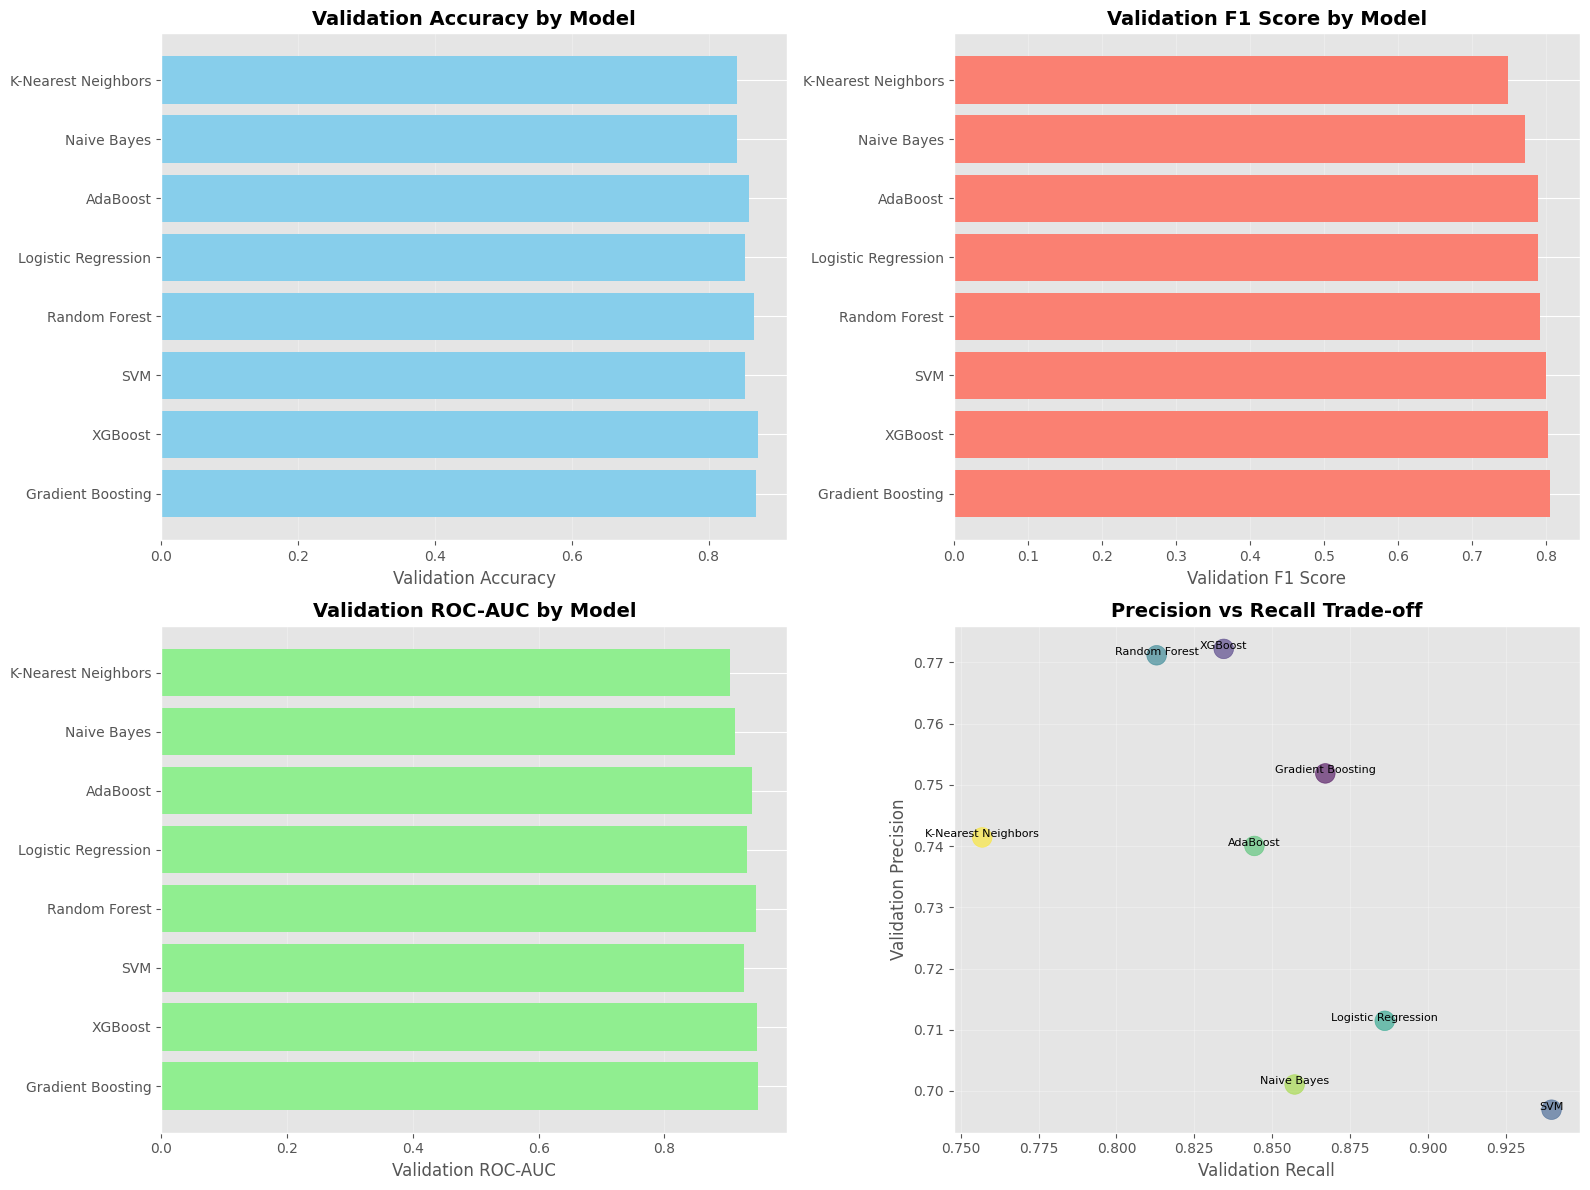

In [11]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Validation Accuracy
axes[0, 0].barh(comparison_df['Model'], comparison_df['Val Accuracy'], color='skyblue')
axes[0, 0].set_xlabel('Validation Accuracy', fontsize=12)
axes[0, 0].set_title('Validation Accuracy by Model', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Validation F1 Score
axes[0, 1].barh(comparison_df['Model'], comparison_df['Val F1'], color='salmon')
axes[0, 1].set_xlabel('Validation F1 Score', fontsize=12)
axes[0, 1].set_title('Validation F1 Score by Model', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Validation ROC-AUC
axes[1, 0].barh(comparison_df['Model'], comparison_df['Val ROC-AUC'], color='lightgreen')
axes[1, 0].set_xlabel('Validation ROC-AUC', fontsize=12)
axes[1, 0].set_title('Validation ROC-AUC by Model', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Validation Precision vs Recall
axes[1, 1].scatter(comparison_df['Val Recall'], comparison_df['Val Precision'], 
                   s=200, alpha=0.6, c=range(len(comparison_df)), cmap='viridis')
for i, model in enumerate(comparison_df['Model']):
    axes[1, 1].annotate(model, (comparison_df['Val Recall'].iloc[i], 
                             comparison_df['Val Precision'].iloc[i]),
                       fontsize=8, ha='center')
axes[1, 1].set_xlabel('Validation Recall', fontsize=12)
axes[1, 1].set_ylabel('Validation Precision', fontsize=12)
axes[1, 1].set_title('Precision vs Recall Trade-off', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Select Best Model


In [12]:
# Select best model based on validation F1 score (balanced metric)
# You can change this to use ROC-AUC or other metrics
best_model_name = comparison_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_metrics = results[best_model_name]

print("=" * 60)
print(f"BEST MODEL: {best_model_name}")
print("=" * 60)
print(f"\nValidation Metrics:")
print(f"  Accuracy:  {best_metrics['val_accuracy']:.4f}")
print(f"  Precision: {best_metrics['val_precision']:.4f}")
print(f"  Recall:    {best_metrics['val_recall']:.4f}")
print(f"  F1 Score:  {best_metrics['val_f1']:.4f}")
print(f"  ROC-AUC:   {best_metrics['val_roc_auc']:.4f}")


BEST MODEL: Gradient Boosting

Validation Metrics:
  Accuracy:  0.8694
  Precision: 0.7519
  Recall:    0.8671
  F1 Score:  0.8054
  ROC-AUC:   0.9482


## 8. Evaluate Best Model on Test Set


In [13]:
# Evaluate best model on test set
needs_scaling = best_metrics['needs_scaling']

if needs_scaling:
    X_test_use = X_test_scaled
else:
    X_test_use = X_test

# Make predictions on test set
y_test_pred = best_model.predict(X_test_use)
y_test_proba = best_model.predict_proba(X_test_use)[:, 1]

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print("=" * 60)
print(f"BEST MODEL TEST SET EVALUATION: {best_model_name}")
print("=" * 60)
print(f"\nTest Metrics:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")
print(f"  ROC-AUC:   {test_roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0, 0]}")
print(f"  False Positives: {cm[0, 1]}")
print(f"  False Negatives: {cm[1, 0]}")
print(f"  True Positives:  {cm[1, 1]}")

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Not Dropout', 'Dropout']))


BEST MODEL TEST SET EVALUATION: Gradient Boosting

Test Metrics:
  Accuracy:  0.8773
  Precision: 0.7734
  Recall:    0.8572
  F1 Score:  0.8132
  ROC-AUC:   0.9502

Confusion Matrix:
  True Negatives:  3978
  False Positives: 510
  False Negatives: 290
  True Positives:  1741

Classification Report:
              precision    recall  f1-score   support

 Not Dropout       0.93      0.89      0.91      4488
     Dropout       0.77      0.86      0.81      2031

    accuracy                           0.88      6519
   macro avg       0.85      0.87      0.86      6519
weighted avg       0.88      0.88      0.88      6519



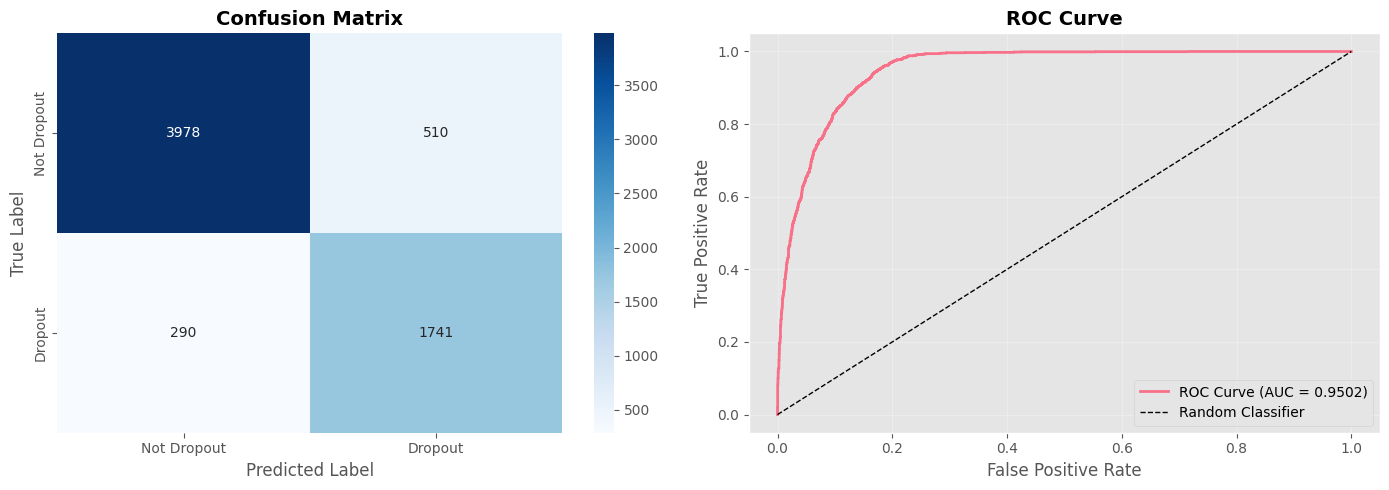

In [14]:
# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Dropout', 'Dropout'],
            yticklabels=['Not Dropout', 'Dropout'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {test_roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Feature Importance (if available)


TOP 20 MOST IMPORTANT FEATURES (Gradient Boosting)
(Note: Data leakage features excluded)
                   feature  importance
              last_vle_day    0.814128
       last_assessment_day    0.074922
      vle_interaction_days    0.020757
           studied_credits    0.017059
      max_assessment_score    0.016058
module_presentation_length    0.008762
             first_vle_day    0.008234
      first_assessment_day    0.005053
         days_before_start    0.003558
           num_assessments    0.003454
         date_registration    0.003452
      min_assessment_score    0.003386
         presentation_year    0.002802
          total_vle_clicks    0.002683
        weighted_avg_score    0.002551
            region_encoded    0.002077
      avg_assessment_score    0.001927
      num_of_prev_attempts    0.001911
       vle_engagement_rate    0.001448
 highest_education_encoded    0.001302


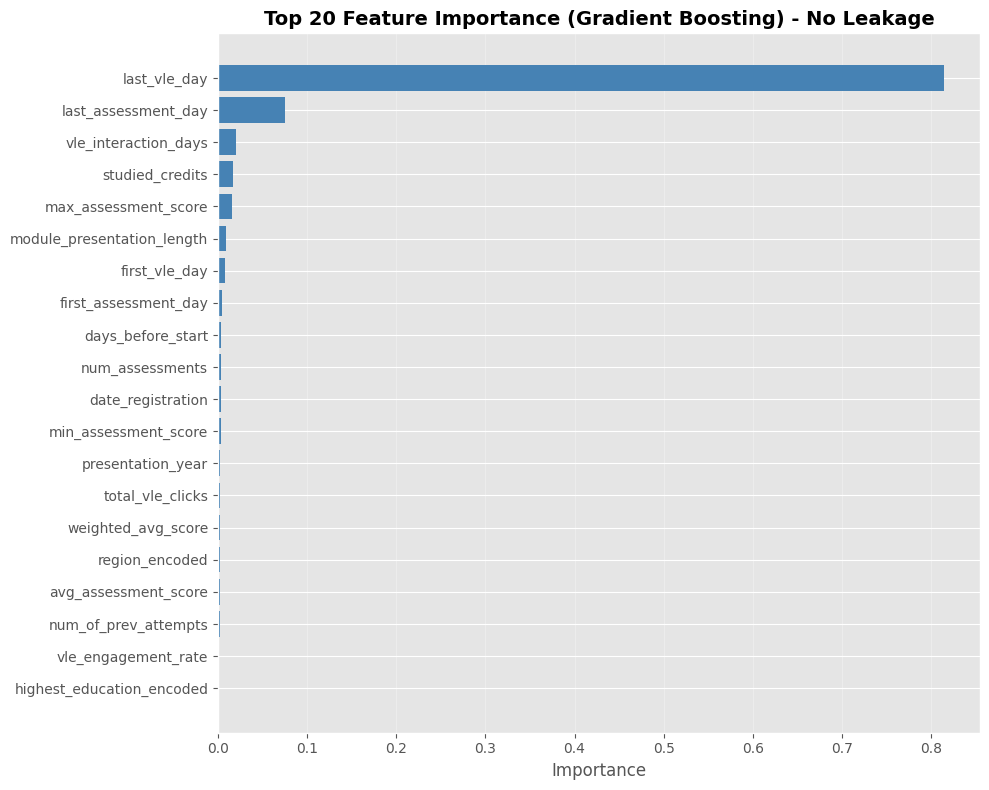

In [15]:
# Get feature importance if the model supports it
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("=" * 60)
    print(f"TOP 20 MOST IMPORTANT FEATURES ({best_model_name})")
    print("=" * 60)
    print("(Note: Data leakage features excluded)")
    print(feature_importance.head(20).to_string(index=False))
    
    # Visualize top features
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Top 20 Feature Importance ({best_model_name}) - No Leakage', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    # For linear models, use coefficients
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'coefficient': best_model.coef_[0]
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print("=" * 60)
    print(f"TOP 20 MOST IMPORTANT FEATURES ({best_model_name} - Coefficients)")
    print("=" * 60)
    print("(Note: Data leakage features excluded)")
    print(feature_importance.head(20).to_string(index=False))
    
    # Visualize top features
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    colors = ['red' if x < 0 else 'green' for x in top_features['coefficient']]
    plt.barh(range(len(top_features)), top_features['coefficient'], color=colors)
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Coefficient', fontsize=12)
    plt.title(f'Top 20 Feature Coefficients ({best_model_name}) - No Leakage', fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"Model {best_model_name} does not support feature importance extraction.")


In [16]:
# Create models directory
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# Save the best model (with suffix to indicate no leakage)
model_file = os.path.join(models_dir, 'best_dropout_model_no_leakage.pkl')
joblib.dump(best_model, model_file)
print(f"✓ Saved best model to: {model_file}")

# Save the scaler if needed
if best_metrics['needs_scaling']:
    scaler_file = os.path.join(models_dir, 'scaler_no_leakage.pkl')
    joblib.dump(scaler, scaler_file)
    print(f"✓ Saved scaler to: {scaler_file}")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'model_type': type(best_model).__name__,
    'needs_scaling': best_metrics['needs_scaling'],
    'feature_columns': feature_cols,
    'excluded_leakage_features': ['has_unregistration', 'date_unregistration', 'days_until_unregistration'],
    'test_accuracy': float(test_accuracy),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'test_f1': float(test_f1),
    'test_roc_auc': float(test_roc_auc),
    'val_accuracy': float(best_metrics['val_accuracy']),
    'val_f1': float(best_metrics['val_f1']),
    'val_roc_auc': float(best_metrics['val_roc_auc'])
}

metadata_file = os.path.join(models_dir, 'model_metadata_no_leakage.json')
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved model metadata to: {metadata_file}")

# Save comparison results
comparison_file = os.path.join(models_dir, 'model_comparison_no_leakage.csv')
comparison_df.to_csv(comparison_file, index=False)
print(f"✓ Saved model comparison to: {comparison_file}")

print(f"\n✓ All files saved successfully!")


✓ Saved best model to: models/best_dropout_model_no_leakage.pkl
✓ Saved model metadata to: models/model_metadata_no_leakage.json
✓ Saved model comparison to: models/model_comparison_no_leakage.csv

✓ All files saved successfully!


## 11. Summary


In [17]:
print("=" * 60)
print("MODEL TRAINING SUMMARY (WITHOUT DATA LEAKAGE)")
print("=" * 60)
print(f"\nTotal models trained: {len(models)}")
print(f"Best model: {best_model_name}")
print(f"\nExcluded leakage features:")
print("  - has_unregistration")
print("  - date_unregistration")
print("  - days_until_unregistration")
print(f"\nBest Model Performance:")
print(f"  Validation F1:  {best_metrics['val_f1']:.4f}")
print(f"  Validation ROC-AUC: {best_metrics['val_roc_auc']:.4f}")
print(f"  Test F1:        {test_f1:.4f}")
print(f"  Test ROC-AUC:   {test_roc_auc:.4f}")
print(f"\nModel saved to: models/best_dropout_model_no_leakage.pkl")
print(f"\n✓ Training complete!")
print(f"\nNote: This model provides realistic performance metrics")
print(f"      that would be achievable in a real-world early warning system.")


MODEL TRAINING SUMMARY (WITHOUT DATA LEAKAGE)

Total models trained: 8
Best model: Gradient Boosting

Excluded leakage features:
  - has_unregistration
  - date_unregistration
  - days_until_unregistration

Best Model Performance:
  Validation F1:  0.8054
  Validation ROC-AUC: 0.9482
  Test F1:        0.8132
  Test ROC-AUC:   0.9502

Model saved to: models/best_dropout_model_no_leakage.pkl

✓ Training complete!

Note: This model provides realistic performance metrics
      that would be achievable in a real-world early warning system.
